In [19]:
import numpy as np
import pandas as pd
import re

import tensorflow as tf
from tensorflow.keras import layers

from sklearn.feature_extraction.text import CountVectorizer

In [20]:
def generar_diccionario(textos, sw, N):
    cv = CountVectorizer(stop_words = sw, max_features = N)
    cv.fit_transform(textos)
    diccionario = cv.vocabulary_
    diccionario = dict([(palabra, i+2) for i, palabra in enumerate(diccionario)])
    diccionario['DESC'] = 0
    diccionario['PAD'] = 1 
    return diccionario

In [21]:
def procesar_cadena(texto, diccionario, stop_words, T):
    # Identificar palabras en el texto
    palabras = re.findall(r'\b\w+\b', texto.lower())
    palabras = list(filter(lambda x: x not in stop_words, palabras))
    resultado = [] 
    for i in range(0, T):
        if i < len(palabras): 
            if palabras[i] in diccionario:
                resultado.append(diccionario[palabras[i]])
            else:
                resultado.append(diccionario['DESC'])
        else:
            resultado.append(diccionario['PAD'])
    return np.array(resultado)

In [22]:
# Parámetros configurables
N = 20000  # Número de palabras del diccionario
T = 100    # Longitud prefijada de la reseña
EPOCHS = 10
NEURONAS_CAPA = 128

In [23]:
stop_words=['a', 'about', 'an', 'and', 'as', 'at', 'be', 'because', 'been', 
    'being', 'by', 'during', 'each', 'for', 'from', 'he', 'he\'d', 'he\'ll',
    'he\'s', 'her', 'him', 'his', 'how', 'i', 'i\'d', 'i\'ll', 'i\'m', 'i\'ve',
    'if', 'in', 'into', 'it', 'it\'s', 'its', 'let\'s', 'of', 'or', 'our', 
    'out', 'over', 'same', 'she', 'she\'d', 'she\'ll', 'she\'s', 'so', 'some'
    'such', 'than', 'that', 'that\'s', 'the', 'them', 'then', 'there', 'these',
    'they', 'they\'d', 'they\'ll', 'they\'re', 'they\'ve', 'this', 'those',
    'through', 'to', 'until', 'very', 'we', 'we\'d', 'we\'ll', 'we\'re', 
    'we\'ve', 'what', 'what\'s', 'when', 'when\'s', 'where', 'where\'s', 'which',
    'while', 'who', 'who\'s', 'whom', 'why', 'why\'s', 'with', 'would', 
    'wouldn\'t', 'you', 'you\'d', 'you\'ll', 'you\'re', 'you\'ve', 'your', 
    'yours']

In [24]:
path = "/kaggle/input/resenyas-hotel-tripadvisor/tripadvisor_hotel_reviews.csv"
datos = pd.read_csv(path)

In [25]:
# Variable objetivo
y = datos.iloc[:, -1]
num_clases = len(y.unique())

# Codificamos con "one hot" las posibles categorías finales
y = pd.get_dummies(datos['Rating'], columns=['Rating'])

In [26]:
print(y)

           1      2      3      4      5
0      False  False  False   True  False
1      False   True  False  False  False
2      False  False   True  False  False
3      False  False  False  False   True
4      False  False  False  False   True
...      ...    ...    ...    ...    ...
20486  False  False  False  False   True
20487  False  False  False   True  False
20488  False   True  False  False  False
20489   True  False  False  False  False
20490  False   True  False  False  False

[20491 rows x 5 columns]


In [27]:
# Textos de reseñas
textos = datos['Review']

X = []
diccionario = generar_diccionario(textos, stop_words, N)
for texto in textos:
    X.append(procesar_cadena(texto, diccionario, stop_words, T))
    
# X contendrá las reseñas codificadas y rellenas con la misma longitud
X = np.array(X)

/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:409: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['let', 'll', 're', 've', 'wouldn'] not in stop_words.
  warnings.warn(


In [28]:
print(X)

[[    2     3     4 ...     1     1     1]
 [   77    78    79 ...   131   144   130]
 [    2   229    38 ...   277    22   278]
 ...
 [   77    55  1628 ...     1     1     1]
 [    3 10487  3935 ... 15279     0     0]
 [   51    52   684 ...     1     1     1]]


## Modelo 1

In [ ]:
model = tf.keras.Sequential([
  layers.InputLayer(shape=(X.shape[1], 1)),
  layers.Bidirectional(layers.LSTM(units=125, activation="tanh")),
  layers.Dense(64, activation='relu'),
  layers.Dense(5, activation='softmax')])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ bidirectional_2 (Bidirectional)      │ (None, 250)                 │         127,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │          16,064 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 5)                   │             325 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 143,389 (560.11 KB)

 Trainable params: 143,389 (560.11 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [31]:
epochs = 10

history = model.fit(
    X,
    y,
    epochs=epochs
)

Epoch 1/10
641/641 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.4717 - loss: 1.3230
Epoch 2/10
641/641 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.4800 - loss: 1.2802
Epoch 3/10
641/641 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.4832 - loss: 1.2662
Epoch 4/10
641/641 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.4976 - loss: 1.2547
Epoch 5/10
641/641 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.4973 - loss: 1.2410
Epoch 6/10
641/641 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.4901 - loss: 1.2494
Epoch 7/10
641/641 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.4976 - loss: 1.2378
Epoch 8/10
641/641 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.5028 - loss: 1.2257
Epoch 9/10
641/641 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.4995 - loss: 1.2201
Epoch 10/10
641/641 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.4911 - loss: 1.2199


## Modelo 2

In [32]:
from keras.layers import Embedding

N = 50 # Tamaño del vocabulario
D = 50 # Dimensión del embedding

In [33]:
embedding_layer = Embedding(input_dim=N, output_dim=D)
entrada = X
embeddings = embedding_layer(entrada)

print('Representación de {}'.format(str(entrada)))
print(embeddings.numpy())

Representación de [[    2     3     4 ...     1     1     1]
 [   77    78    79 ...   131   144   130]
 [    2   229    38 ...   277    22   278]
 ...
 [   77    55  1628 ...     1     1     1]
 [    3 10487  3935 ... 15279     0     0]
 [   51    52   684 ...     1     1     1]]
[[[ 0.02346423 -0.03825833  0.03100351 ...  0.01349184  0.00857585
    0.03995719]
  [-0.0351558   0.01616878  0.02748609 ...  0.01597956  0.03556849
   -0.0330781 ]
  [ 0.00762777 -0.03728163 -0.04937041 ...  0.04832503  0.00573818
   -0.03841057]
  ...
  [-0.03160864 -0.00599032 -0.0026014  ... -0.01619742  0.04457638
   -0.00083867]
  [-0.03160864 -0.00599032 -0.0026014  ... -0.01619742  0.04457638
   -0.00083867]
  [-0.03160864 -0.00599032 -0.0026014  ... -0.01619742  0.04457638
   -0.00083867]]

 [[ 0.          0.          0.         ...  0.          0.
    0.        ]
  [ 0.          0.          0.         ...  0.          0.
    0.        ]
  [ 0.          0.          0.         ...  0.          0.
   

In [ ]:
model2 = tf.keras.Sequential([
  layers.Embedding(input_dim=N, output_dim=D),
  layers.Bidirectional(layers.LSTM(units=125, activation="tanh")),
  layers.Dense(64, activation='relu'),
  layers.Dense(5, activation='softmax')])

model2.summary()

model2.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_3 (Bidirectional)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [36]:
epochs = 10

history2 = model2.fit(
    X,
    y,
    epochs=epochs,
    verbose=1,
    validation_split=0.2
)

Epoch 1/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.4936 - loss: 1.2050 - val_accuracy: 0.5313 - val_loss: 1.1639
Epoch 2/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.5132 - loss: 1.1763 - val_accuracy: 0.5499 - val_loss: 1.1385
Epoch 3/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.5052 - loss: 1.1770 - val_accuracy: 0.5492 - val_loss: 1.1427
Epoch 4/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.5170 - loss: 1.1625 - val_accuracy: 0.5411 - val_loss: 1.1273
Epoch 5/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.5207 - loss: 1.1518 - val_accuracy: 0.5475 - val_loss: 1.1351
Epoch 6/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.5251 - loss: 1.1405 - val_accuracy: 0.5501 - val_loss: 1.1179
Epoch 7/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.5284 - loss: 1.1356 - val_accuracy: 0.5538 - val_loss: 1.1142
Epoch 8/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.5220 - loss: 1.1466 - val_accu

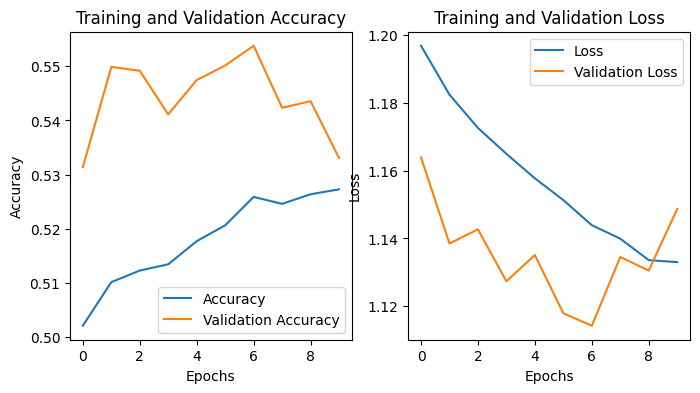

In [ ]:
import matplotlib.pyplot as plt

history_dict = history2.history

acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']

loss = history_dict['loss']
val_loss = history_dict['val_loss']

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.plot(acc)
plt.plot(val_acc)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Accuracy', 'Validation Accuracy'])

plt.subplot(1, 2, 2)
plt.plot(loss)
plt.plot(val_loss)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Loss', 'Validation Loss'])

plt.show()